# Graphormer top-k layer fine-tuning baseline (target-only)

Check whether performance improves when **the top k layers are unfrozen**, compared with frozen Graphormer embeddings + MLP (01 baseline).

- data split, normalisation and early stopping are the same as the 01 baseline (scaffold 5-fold, inner scaffold val, val R² early stopping, test only for final evaluation)
- head architecture, head learning rate (1e-3), Huber, AdamW and batch 32 are also the same → **the only difference is unfreezing**
- the seed formula (`seed*100+fold`) matches 08, so a per-fold paired comparison with the frozen baseline (`results/significance/runs.csv`) is possible

Run with **kernel: `esu_gpu (CUDA)`**.

For speed, the lower Graphormer layers (0-7) are computed once per molecule and cached; only the upper layers run during training.

## 0. Settings

In [28]:
import copy
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_rel
from sklearn.metrics import r2_score

ROOT = r'..'
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, '01_model'))
from src.graphormer_encoder import load_encoder, embed
from src.graphormer_preprocess import collate, preprocess_smiles
from train_utils import split_train_val, fit_early_stopping

DATA_DIR = os.path.join(ROOT, 'data', 'cv_datasets')
OUT_DIR = os.path.join(ROOT, 'results', 'finetune')
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROPERTIES = ['clearance', 'half_life', 'fu']
N_FOLDS = 5
SEEDS = [0, 1, 2]
K_VALUES = [1, 2, 4]      # number of top layers to unfreeze (<= 12 - CACHE_LAYER)
LR_BACKBONE = 2e-5        # unfrozen Graphormer layers
LR_HEAD = 1e-3            # MLP head (same as the 01 baseline)
WEIGHT_DECAY = 1e-4
BATCH = 32
CACHE_LAYER = 8           # cache the output of layers 0-7 → supports k <= 4
MAX_NODES = 128           # same as the 08 embedding extraction

print('Device:', DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else '')
assert DEVICE.type == 'cuda', 'Please switch the kernel to esu_gpu (CUDA)'

Device: cuda NVIDIA GeForce RTX 3060


## 1. Cache the lower Graphormer layers

Store the per-molecule hidden state (output of layers 0-7) and attention bias. Padded keys are hidden by the padding mask, so caching per molecule and re-batching gives the same result.

In [29]:
def _prefix(enc, batch):
    """Run encoder.forward only up to CACHE_LAYER → (x[T,B,C], attn_bias[B,H,T,T], lengths[B])"""
    x_in = batch['input_nodes']
    pm = x_in[:, :, 0].eq(0)
    pm = torch.cat([torch.zeros(x_in.size(0), 1, dtype=pm.dtype, device=x_in.device), pm], 1)
    ab = enc.graph_attn_bias(x_in, batch['attn_bias'], batch['spatial_pos'], batch['input_edges'], batch['attn_edge_type'])
    x = enc.graph_node_feature(x_in, batch['in_degree'], batch['out_degree'])
    if enc.emb_layer_norm is not None:
        x = enc.emb_layer_norm(x)
    x = x.transpose(0, 1)
    for layer in enc.layers[:CACHE_LAYER]:
        x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
    return x, ab, (~pm).sum(1)


@torch.no_grad()
def build_cache(enc, cfg, smiles_list, batch_size=32):
    items, keys = [], []
    for s in smiles_list:
        it = preprocess_smiles(s)
        if it is not None and it['num_nodes'] <= MAX_NODES:
            items.append(it)
            keys.append(s)
    cache = {}
    for i in range(0, len(items), batch_size):
        b = {k: v.to(DEVICE) for k, v in collate(items[i:i + batch_size], spatial_pos_max=cfg.spatial_pos_max).items()}
        x, ab, n = _prefix(enc, b)
        for j, s in enumerate(keys[i:i + batch_size]):
            t = int(n[j])
            cache[s] = (x[:t, j].cpu().clone(), ab[j, :, :t, :t].cpu().clone())
    return cache


def pad_batch(entries):
    T = max(h.shape[0] for h, _ in entries)
    B, C, H = len(entries), entries[0][0].shape[1], entries[0][1].shape[0]
    x, ab, pm = torch.zeros(T, B, C), torch.zeros(B, H, T, T), torch.ones(B, T, dtype=torch.bool)
    for j, (h, b) in enumerate(entries):
        t = h.shape[0]
        x[:t, j], ab[j, :, :t, :t], pm[j, :t] = h, b, False
    return x.to(DEVICE), ab.to(DEVICE), pm.to(DEVICE)

In [30]:
enc, cfg = load_encoder(DEVICE)
enc.eval()

all_smiles = set()
for prop in PROPERTIES:
    for fold in range(N_FOLDS):
        for split in ['train', 'test']:
            all_smiles.update(pd.read_csv(os.path.join(DATA_DIR, f'fold_{fold}', f'{prop}_target_{split}.csv'))['smiles'].astype(str))

t0 = time.time()
cache = build_cache(enc, cfg, sorted(all_smiles))
print(f'cache: {len(cache)}/{len(all_smiles)} molecules ({time.time() - t0:.0f}s)')

[graphormer] loaded 202 tensors | missing=0 unexpected=0
cache: 1211/1211 molecules (8s)


In [31]:
# Cache check: does cache → remaining layers (frozen) match the original full forward?
with torch.no_grad():
    sample = sorted(cache)[:16]
    ref = embed(enc, collate([preprocess_smiles(s) for s in sample], spatial_pos_max=cfg.spatial_pos_max), DEVICE)
    x, ab, pm = pad_batch([cache[s] for s in sample])
    for layer in enc.layers[CACHE_LAYER:]:
        x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
    diff = float((x[0].cpu() - ref).abs().max())
print(f'max |Δ| vs full forward: {diff:.2e}')
assert diff < 1e-4

max |Δ| vs full forward: 6.20e-06


## 2. Model

Only the top k layers are trained (a fresh copy per model); layers 8-(11−k) below them are frozen and in eval mode. The head is the same 768→256→128→1 MLP as the 01 baseline (`DirectRegressionModel`).

In [32]:
class FTRegressor(nn.Module):
    def __init__(self, enc, k, d_hidden=256, dropout=0.2):
        super().__init__()
        n_layers = len(enc.layers)
        assert 0 <= k <= n_layers - CACHE_LAYER
        self.mid = nn.ModuleList(enc.layers[CACHE_LAYER:n_layers - k])               # shared, frozen
        self.top = nn.ModuleList([copy.deepcopy(l) for l in enc.layers[n_layers - k:]])  # trained
        for p in self.mid.parameters():
            p.requires_grad_(False)
        for p in self.top.parameters():
            p.requires_grad_(True)
        d = enc.embedding_dim
        self.head = nn.Sequential(
            nn.Linear(d, d_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_hidden // 2, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.mid.eval()  # frozen layers always run without dropout
        return self

    def forward(self, x, ab, pm):
        with torch.no_grad():
            for layer in self.mid:
                x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
        for layer in self.top:
            x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
        return self.head(x[0]).squeeze(-1)

    def param_groups(self):
        groups = [{'params': self.head.parameters(), 'lr': LR_HEAD, 'weight_decay': WEIGHT_DECAY}]
        if len(self.top):
            groups.append({'params': self.top.parameters(), 'lr': LR_BACKBONE, 'weight_decay': WEIGHT_DECAY})
        return groups


for k in K_VALUES:
    m = FTRegressor(enc, k)
    print(f'k={k}: trainable params {sum(p.numel() for p in m.parameters() if p.requires_grad):,}')

k=1: trainable params 3,776,513
k=2: trainable params 7,323,137
k=4: trainable params 14,416,385


## 3. Training and evaluation functions

In [33]:
def load_split(prop, fold, split):
    df = pd.read_csv(os.path.join(DATA_DIR, f'fold_{fold}', f'{prop}_target_{split}.csv'))
    keep = [(s, y) for s, y in zip(df['smiles'].astype(str), df['value']) if s in cache]
    return [s for s, _ in keep], np.array([y for _, y in keep], dtype='float32')


@torch.no_grad()
def predict(model, smiles):
    model.eval()
    return np.concatenate([model(*pad_batch([cache[s] for s in smiles[i:i + 128]])).cpu().numpy()
                           for i in range(0, len(smiles), 128)])


@torch.no_grad()
def evaluate(model, smiles, y):
    model.eval()
    p = np.concatenate([model(*pad_batch([cache[s] for s in smiles[i:i + 128]])).cpu().numpy()
                        for i in range(0, len(smiles), 128)])
    return {'r2': r2_score(y, p), 'rho': spearmanr(y, p)[0], 'rmse': float(np.sqrt(np.mean((y - p) ** 2))), 'mae': float(np.mean(np.abs(y - p)))}


def train_epoch(model, smiles, y, opt, crit):
    model.train()
    perm = np.random.permutation(len(smiles))
    for i in range(0, len(smiles), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad()
        loss = crit(model(*pad_batch([cache[smiles[j]] for j in idx])), torch.tensor(y[idx], device=DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()


PRED_ROWS = []  # where run_one accumulates per-compound predictions (re-initialised from the file in the full-run cell 5)


def run_one(prop, fold, k, seed):
    tr_s, tr_y = load_split(prop, fold, 'train')
    te_s, te_y = load_split(prop, fold, 'test')
    tr_i, _, va_i, _ = split_train_val(np.arange(len(tr_s)), tr_y, fold, smiles=tr_s)
    fit_s, fit_y = [tr_s[i] for i in tr_i], tr_y[tr_i]
    val_s, val_y = [tr_s[i] for i in va_i], tr_y[va_i]

    torch.manual_seed(seed * 100 + fold)
    np.random.seed(seed * 100 + fold)
    model = FTRegressor(enc, k).to(DEVICE)
    opt = torch.optim.AdamW(model.param_groups())
    crit = nn.HuberLoss(delta=1.0)

    t = time.time()
    best_epoch, best_val = fit_early_stopping(
        model, lambda: train_epoch(model, fit_s, fit_y, opt, crit),
        lambda m, X, Y: evaluate(m, X, Y), val_s, val_y)
    PRED_ROWS.append(pd.DataFrame({'property': prop, 'k': k, 'seed': seed, 'fold': fold, 'smiles': te_s,
                                   'y_true': te_y, 'y_pred': predict(model, te_s)}))
    return {'property': prop, 'k': k, 'seed': seed, 'fold': fold, **evaluate(model, te_s, te_y),
            'val_r2': best_val, 'best_epoch': best_epoch, 'sec': time.time() - t}

## 4. Quick check (optional)

Run k=0 (frozen), 2 and 4 on fu, fold 0 only to check behaviour and timing. Can be skipped.

In [34]:
for k in [0, 2, 4]:
    r = run_one('fu', 0, k, seed=0)
    print(f"k={k}: test r2={r['r2']:.3f} rho={r['rho']:.3f} | best_epoch={r['best_epoch']} val_r2={r['val_r2']:.3f} | {r['sec']:.1f}s")

k=0: test r2=0.212 rho=0.531 | best_epoch=5 val_r2=0.319 | 6.0s
k=2: test r2=0.318 rho=0.570 | best_epoch=20 val_r2=0.321 | 13.5s
k=4: test r2=0.320 rho=0.580 | best_epoch=4 val_r2=0.342 | 10.4s


## 5. Full run

3 properties × 3 k values × 3 seeds × 5 folds = 135 runs (about 1 hour). Results are saved continuously to `results/finetune/runs.csv`; **if interrupted, re-running skips finished combinations.**

In [35]:
runs_path = os.path.join(OUT_DIR, 'runs.csv')
rows = pd.read_csv(runs_path).to_dict('records') if os.path.exists(runs_path) else []
done = {(r['property'], r['k'], r['seed'], r['fold']) for r in rows}
KEY_COLS = ['property', 'k', 'seed', 'fold']
# Per-compound test predictions (y_true and y_pred in per-fold z-score units). Combinations already in runs.csv are skipped,
# so to collect predictions again, move the existing runs.csv to another name (e.g. runs_v1.csv) before running.
preds_path = os.path.join(OUT_DIR, 'predictions.csv')
PRED_ROWS = [pd.read_csv(preds_path)] if os.path.exists(preds_path) else []
pred_done = set(map(tuple, PRED_ROWS[0][KEY_COLS].drop_duplicates().to_numpy())) if PRED_ROWS else set()
if done - pred_done:
    print(f'Warning: {len(done - pred_done)} combinations are only in runs.csv without predictions → move runs.csv and re-run to save predictions as well')
print(f'Already done: {len(done)} runs')

t0 = time.time()
for prop in PROPERTIES:
    for k in K_VALUES:
        for seed in SEEDS:
            new = 0
            for fold in range(N_FOLDS):
                if (prop, k, seed, fold) in done:
                    continue
                rows.append(run_one(prop, fold, k, seed))
                new += 1
            if new:
                pd.DataFrame(rows).to_csv(runs_path, index=False)
                pd.concat(PRED_ROWS, ignore_index=True).to_csv(preds_path, index=False)
                last = pd.DataFrame(rows)
                last = last[(last['property'] == prop) & (last['k'] == k) & (last['seed'] == seed)]
                print(f'{prop:<10} k={k} seed={seed} | test r2={last["r2"].mean():.4f} | '
                      f'best_epoch={last["best_epoch"].mean():.1f} | {time.time() - t0:.0f}s')

runs = pd.DataFrame(rows)
print('Done:', len(runs), 'runs')

Already done: 0 runs
clearance  k=1 seed=0 | test r2=0.0974 | best_epoch=8.4 | 115s
clearance  k=1 seed=1 | test r2=0.1145 | best_epoch=8.4 | 233s
clearance  k=1 seed=2 | test r2=0.0977 | best_epoch=10.8 | 360s
clearance  k=2 seed=0 | test r2=0.1162 | best_epoch=11.2 | 513s
clearance  k=2 seed=1 | test r2=0.0867 | best_epoch=10.4 | 661s
clearance  k=2 seed=2 | test r2=0.0840 | best_epoch=12.8 | 821s
clearance  k=4 seed=0 | test r2=0.0999 | best_epoch=19.4 | 1091s
clearance  k=4 seed=1 | test r2=0.0931 | best_epoch=13.8 | 1316s
clearance  k=4 seed=2 | test r2=0.0763 | best_epoch=8.6 | 1509s
half_life  k=1 seed=0 | test r2=0.0945 | best_epoch=5.4 | 1624s
half_life  k=1 seed=1 | test r2=0.1004 | best_epoch=4.6 | 1733s
half_life  k=1 seed=2 | test r2=0.0866 | best_epoch=5.4 | 1849s
half_life  k=2 seed=0 | test r2=0.0655 | best_epoch=7.4 | 1997s
half_life  k=2 seed=1 | test r2=0.0843 | best_epoch=5.0 | 2128s
half_life  k=2 seed=2 | test r2=0.0920 | best_epoch=7.2 | 2274s
half_life  k=4 seed

## 6. Comparison with the frozen baseline

frozen = Baseline of 08 multi-seed (same seeds 0-2, same folds). Paired t-test on per-fold seed means (n=5).

In [36]:
runs = pd.read_csv(runs_path)
frozen = pd.read_csv(os.path.join(ROOT, 'results', 'significance', 'runs.csv'))
frozen = frozen[(frozen['method'] == 'Baseline') & (frozen['seed'].isin(SEEDS))]

out = []
for prop in PROPERTIES:
    f = frozen[frozen['property'] == prop]
    f_fold = f.groupby('fold')['r2'].mean()
    out.append({'property': prop, 'model': 'frozen (k=0)', 'r2_mean': f['r2'].mean(), 'rho_mean': f['rho'].mean(),
                'rmse_mean': f['rmse'].mean(), 'best_epoch_mean': f['best_epoch'].mean()})
    for k in K_VALUES:
        d = runs[(runs['property'] == prop) & (runs['k'] == k)]
        if d.empty:
            continue
        d_fold = d.groupby('fold')['r2'].mean()
        out.append({'property': prop, 'model': f'fine-tune k={k}', 'r2_mean': d['r2'].mean(), 'rho_mean': d['rho'].mean(),
                    'rmse_mean': d['rmse'].mean(), 'best_epoch_mean': d['best_epoch'].mean(),
                    'delta_r2': (d_fold - f_fold).mean(), 'p_ttest': ttest_rel(d_fold, f_fold).pvalue})
summary = pd.DataFrame(out)
summary.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False)
summary.style.format({'r2_mean': '{:.4f}', 'rho_mean': '{:.4f}', 'rmse_mean': '{:.4f}', 'best_epoch_mean': '{:.1f}',
                      'delta_r2': '{:+.4f}', 'p_ttest': '{:.3f}'}, na_rep='–')

,property,model,r2_mean,rho_mean,rmse_mean,best_epoch_mean,delta_r2,p_ttest
0,clearance,frozen (k=0),0.0999,0.3714,0.9465,14.8,–,–
1,clearance,fine-tune k=1,0.1032,0.3659,0.9442,9.2,+0.0033,0.841
2,clearance,fine-tune k=2,0.0956,0.3775,0.9478,11.5,-0.0043,0.813
3,clearance,fine-tune k=4,0.0898,0.3673,0.9500,13.9,-0.0101,0.681
4,half_life,frozen (k=0),0.1067,0.4052,0.9376,8.9,–,–
5,half_life,fine-tune k=1,0.0938,0.4002,0.9442,5.1,-0.0129,0.197
6,half_life,fine-tune k=2,0.0806,0.4046,0.9494,6.5,-0.0261,0.296
7,half_life,fine-tune k=4,0.1131,0.4285,0.9327,8.4,+0.0064,0.753
8,fu,frozen (k=0),0.2485,0.5856,0.8448,9.5,–,–
9,fu,fine-tune k=1,0.2427,0.5891,0.8461,12.4,-0.0058,0.811


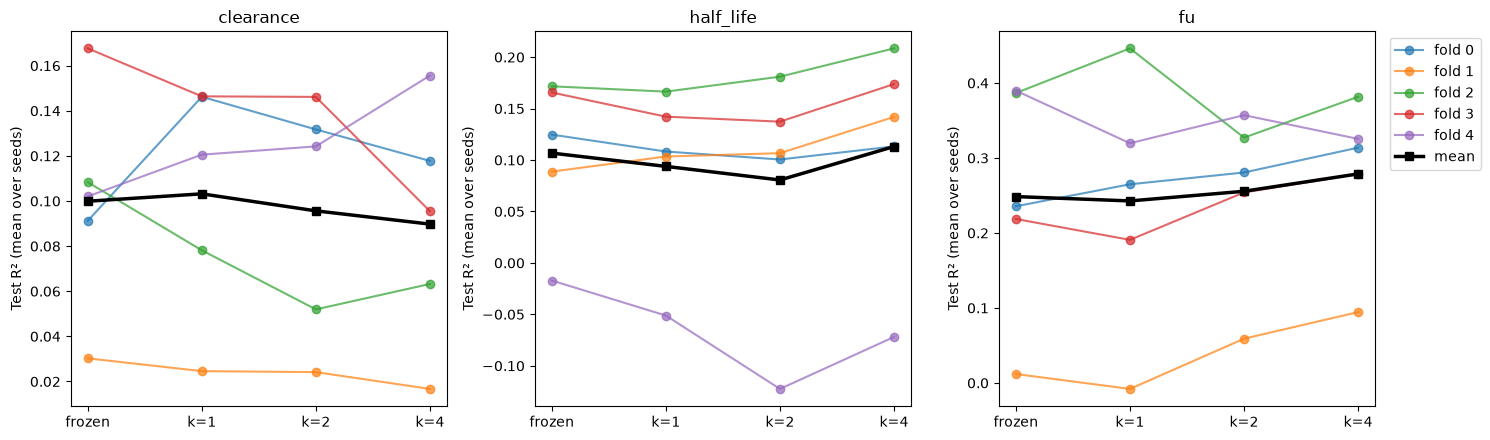

In [37]:
fold_r2 = pd.concat([
    frozen.assign(model='frozen')[['property', 'model', 'fold', 'r2']],
    runs.assign(model=runs['k'].map(lambda k: f'k={k}'))[['property', 'model', 'fold', 'r2']],
]).groupby(['property', 'model', 'fold'])['r2'].mean().reset_index()
order = ['frozen'] + [f'k={k}' for k in K_VALUES]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, prop in zip(axes, PROPERTIES):
    piv = fold_r2[fold_r2['property'] == prop].pivot(index='fold', columns='model', values='r2').reindex(columns=order)
    for fold, row in piv.iterrows():
        ax.plot(range(len(order)), row.values, marker='o', alpha=0.7, label=f'fold {fold}')
    ax.plot(range(len(order)), piv.mean().values, color='black', lw=2.5, marker='s', label='mean')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_title(prop)
    ax.set_ylabel('Test R² (mean over seeds)')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()